# State Grid Renewable — Solar Stations EDA

EDA of the **State Grid renewable-generation forecasting competition** solar data:
**8 PV stations**, **2019–2020**, **15-minute** sampling. Per record: three
irradiance channels (total / direct-normal / global-horizontal), **air
temperature**, **atmospheric pressure**, relative humidity, and **power (MW)**.
Nominal capacity per station is encoded in the file name (30–130 MW).

Source: `data/raw/Renewable/.../data_original/solar_stations` — the **raw** files
(chosen over `data_processed`, whose cleaning is inconsistent across stations:
different column sets, site 3 drops temperature and 60% of its rows). EDA on the
raw data is what surfaces the issues you must handle before modelling.

In [1]:
import re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4)
DIR = ("/Users/lin_/Solar_Prediction/data/raw/Renewable/"
       "Renewable-energy-generation-input-feature-variables-analysis-main/"
       "data_original/solar_stations")

FEATCOLS = ["irr_total", "dni", "ghi", "temp", "pressure", "humidity", "power"]
EXPECTED_FULL = 96 * 731   # 15-min steps across all of 2019-2020 (731 days)

def _rename(df):
    m = {}
    for c in df.columns:
        cl = str(c).strip().lower()
        if   cl.startswith("time"):        m[c] = "ts"
        elif "total solar" in cl:          m[c] = "irr_total"
        elif "direct normal" in cl:        m[c] = "dni"
        elif "global hori" in cl:          m[c] = "ghi"   # note: site 2 header typo "horicontal"
        elif "temperature" in cl:          m[c] = "temp"
        elif "atmosphere" in cl:           m[c] = "pressure"
        elif "humidity" in cl:             m[c] = "humidity"
        elif "power" in cl:                m[c] = "power"
    return df.rename(columns=m)

def load_station(path):
    cap  = int(re.search(r"capacity-(\d+)MW", path).group(1))
    site = int(re.search(r"site (\d+)", path).group(1))
    raw  = _rename(pd.read_excel(path, sheet_name=0))
    df   = raw.copy()
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    # count non-numeric junk (strings) before coercing them to NaN
    nonnum = {}
    for c in FEATCOLS:
        if c in df.columns:
            coerced = pd.to_numeric(df[c], errors="coerce")
            nonnum[c] = int((coerced.isna() & raw[c].notna()).sum())
            df[c] = coerced
    present = [c for c in FEATCOLS if c in df.columns]
    df["site"], df["capacity"] = site, cap
    df["cf"] = df["power"] / cap                       # capacity factor (comparable across sites)
    t = df["ts"]
    df["date"]  = t.dt.normalize()
    df["month"] = t.dt.month
    df["tod"]   = t.dt.hour * 60 + t.dt.minute         # minute-of-day, 0..1425 step 15
    df["doy"]   = t.dt.dayofyear
    span = (t.max() - t.min()).total_seconds() / 900 + 1
    meta = dict(site=site, capacity=cap, rows=len(df),
                start=t.min(), end=t.max(),
                span_completeness=len(df) / span,
                nonnumeric=sum(nonnum.values()),
                nulls=int(df[present].isna().sum().sum()),
                neg_power=int((df["power"] < 0).sum()),
                over_cap=int((df["power"] > cap).sum()),
                dup_ts=int(df["ts"].duplicated().sum()))
    return df, meta

paths = sorted(glob.glob(DIR + "/*.xlsx"))
frames, metas = [], []
for p in paths:
    d, m = load_station(p)
    frames.append(d); metas.append(m)
    print(f"loaded site{m['site']:>1}  cap={m['capacity']:>3}MW  rows={m['rows']}")
full = pd.concat(frames, ignore_index=True)
meta = pd.DataFrame(metas).set_index("site")
stations = {m["site"]: f for m, f in zip(metas, frames)}
print("combined:", full.shape)

loaded site1  cap= 50MW  rows=70176
loaded site2  cap=130MW  rows=70176
loaded site3  cap= 30MW  rows=52608
loaded site4  cap=130MW  rows=70176
loaded site5  cap=110MW  rows=70176
loaded site6  cap= 35MW  rows=70176
loaded site7  cap= 30MW  rows=70176
loaded site8  cap= 30MW  rows=69408
combined: (543072, 15)


## Dataset preview

A quick look at the combined dataset size, source feature columns, and first five rows.

In [2]:
print("Combined dataset shape:", full.shape)
print("Source feature columns:", FEATCOLS)
print("All columns after loading and feature engineering:", full.columns.tolist())
full.head()

Combined dataset shape: (543072, 15)
Source feature columns: ['irr_total', 'dni', 'ghi', 'temp', 'pressure', 'humidity', 'power']
All columns after loading and feature engineering: ['ts', 'irr_total', 'dni', 'ghi', 'temp', 'pressure', 'humidity', 'power', 'site', 'capacity', 'cf', 'date', 'month', 'tod', 'doy']


,ts,irr_total,dni,ghi,temp,pressure,humidity,power,site,capacity,cf,date,month,tod,doy
0,2019-01-01 00:00:00,0.0,0.0,0.0,-11.7,930.5,39.1,0.0,1,50,0.0,2019-01-01,1,0,1
1,2019-01-01 00:15:00,0.0,0.0,0.0,-11.8,930.5,39.3,0.0,1,50,0.0,2019-01-01,1,15,1
2,2019-01-01 00:30:00,0.0,0.0,0.0,-11.4,930.5,39.0,0.0,1,50,0.0,2019-01-01,1,30,1
3,2019-01-01 00:45:00,0.0,0.0,0.0,-11.5,930.5,38.0,0.0,1,50,0.0,2019-01-01,1,45,1
4,2019-01-01 01:00:00,0.0,0.0,0.0,-11.5,930.4,38.9,0.0,1,50,0.0,2019-01-01,1,60,1


DNI（Direct Normal Irradiance）：直接法向辐照度，表示太阳光沿直线直接照射到“始终正对太阳”的表面上的能量，单位为 W/m²。云层遮挡时会明显下降。

GHI（Global Horizontal Irradiance）：全球水平辐照度，表示水平表面接收到的总太阳辐射，包括直接光和天空散射光，单位也是 W/m²。

CF（Capacity Factor）：容量因子，表示当前实际功率占电站额定容量的比例：

## 0. Per-station overview

Capacity, row count, time span, and completeness relative to a full 2-year 15-min
grid (70 176 steps). Two stations fall short: **site 3** ends 2020-07 (~1.5 yr)
and **site 8** is slightly short.

In [3]:
overview = meta[["capacity", "rows", "start", "end", "span_completeness"]].copy()
overview["vs_full_2yr"] = (meta["rows"] / EXPECTED_FULL).round(3)
overview["span_completeness"] = overview["span_completeness"].round(3)
print(overview.to_string())
print("\nunits: irradiance W/m², temp °C, pressure hPa, humidity %, power MW")
print("total capacity across 8 sites:", meta["capacity"].sum(), "MW")

      capacity   rows      start                 end  span_completeness  vs_full_2yr
site                                                                                
1           50  70176 2019-01-01 2020-12-31 23:45:00              1.000        1.000
2          130  70176 2019-01-01 2020-12-31 23:45:00              1.000        1.000
3           30  52608 2019-01-01 2020-07-01 23:45:00              1.000        0.750
4          130  70176 2019-01-01 2020-12-31 23:45:00              1.000        1.000
5          110  70176 2019-01-01 2020-12-31 23:45:00              1.000        1.000
6           35  70176 2019-01-01 2020-12-31 23:45:00              1.000        1.000
7           30  70176 2019-01-01 2020-12-31 23:45:00              1.000        1.000
8           30  69408 2019-01-01 2020-12-31 23:45:00              0.989        0.989

units: irradiance W/m², temp °C, pressure hPa, humidity %, power MW
total capacity across 8 sites: 545 MW


## 1. Data quality (why raw matters)

The raw files carry real issues the processed set hides: **string junk** in numeric
columns (coerced to NaN here), **negative power** at night (inverter self-draw),
nulls, duplicate timestamps. None exceed capacity. There is also a **header typo**
(site 2 writes "Global hori**c**ontal"), so column matching must be fuzzy. These
must be cleaned/normalised before modelling.

      nonnumeric  nulls  neg_power  over_cap  dup_ts
site                                                
1              0      0          0         0       0
2              0      0          0         0       0
3              0      0      25652         0       0
4              0      6      33878         0       0
5            322    322      18055         0       0
6           3444   3444          0         0       0
7           3465   3465          0         0       0
8              0      0          0         0       0

totals: {'nonnumeric': 7231, 'nulls': 7237, 'neg_power': 77585, 'over_cap': 0, 'dup_ts': 0}


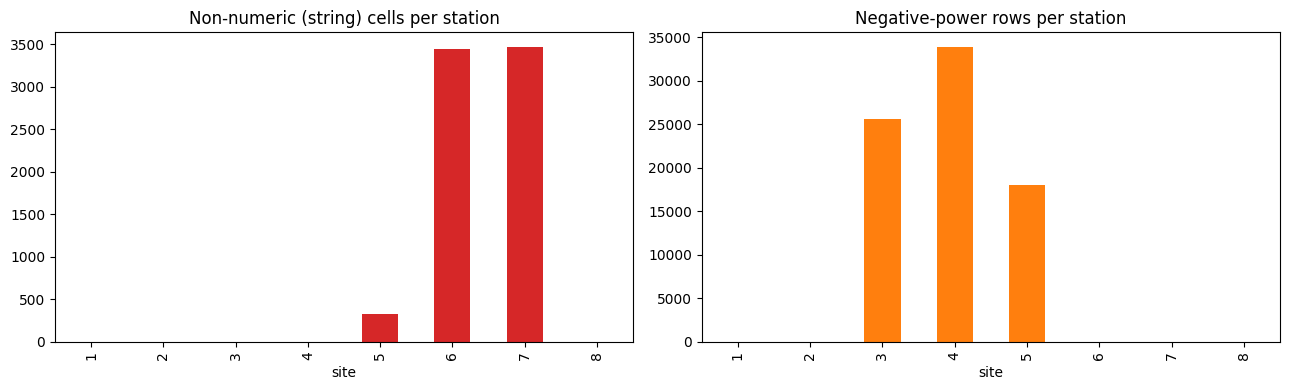

In [4]:
q = meta[["nonnumeric", "nulls", "neg_power", "over_cap", "dup_ts"]]
print(q.to_string())
print("\ntotals:", q.sum().to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
meta["nonnumeric"].plot(kind="bar", ax=ax[0], color="C3")
ax[0].set_title("Non-numeric (string) cells per station"); ax[0].set_xlabel("site")
meta["neg_power"].plot(kind="bar", ax=ax[1], color="C1")
ax[1].set_title("Negative-power rows per station"); ax[1].set_xlabel("site")
plt.tight_layout(); plt.show()

## 2. Power as capacity factor

Stations span 30–130 MW, so raw power is not comparable. **Capacity factor
CF = power / capacity** (dimensionless, ~0–1) puts them on one scale. Below:
CF distribution per site and mean daytime CF.

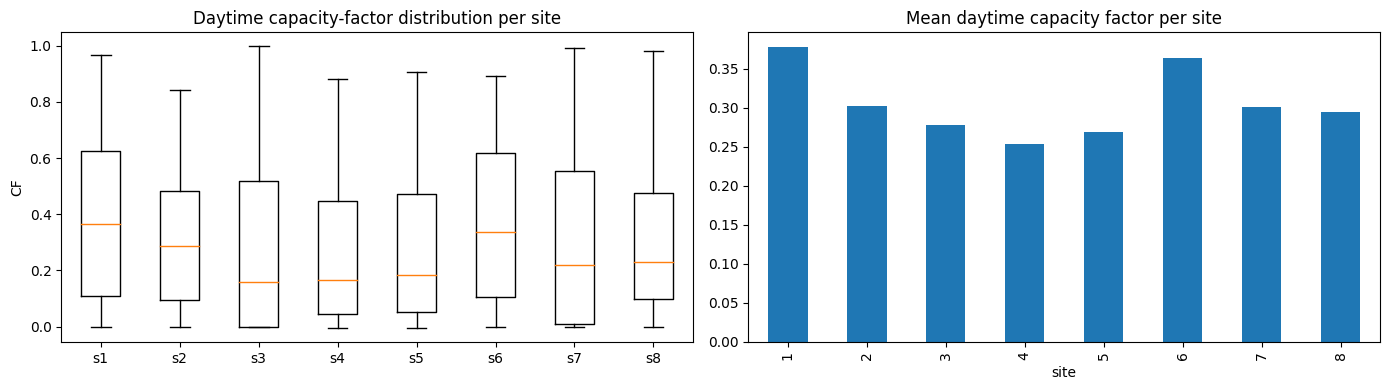

mean daytime CF per site:
 site
1    0.378
2    0.303
3    0.278
4    0.253
5    0.269
6    0.363
7    0.301
8    0.294


In [5]:
day = full[full["irr_total"] > 0]                      # daytime rows
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].boxplot([stations[s].loc[stations[s]["irr_total"] > 0, "cf"].dropna()
               for s in sorted(stations)],
              labels=[f"s{s}" for s in sorted(stations)], showfliers=False)
ax[0].set_title("Daytime capacity-factor distribution per site"); ax[0].set_ylabel("CF")
mean_cf = day.groupby("site")["cf"].mean()
mean_cf.plot(kind="bar", ax=ax[1], color="C0")
ax[1].set_title("Mean daytime capacity factor per site"); ax[1].set_xlabel("site")
plt.tight_layout(); plt.show()
print("mean daytime CF per site:\n", mean_cf.round(3).to_string())

## 3. Diurnal & seasonal structure

CF averaged over the 96 daily 15-min slots (per site), and the pooled
time-of-day × month surface (the seasonal envelope: longer, stronger summer
days).

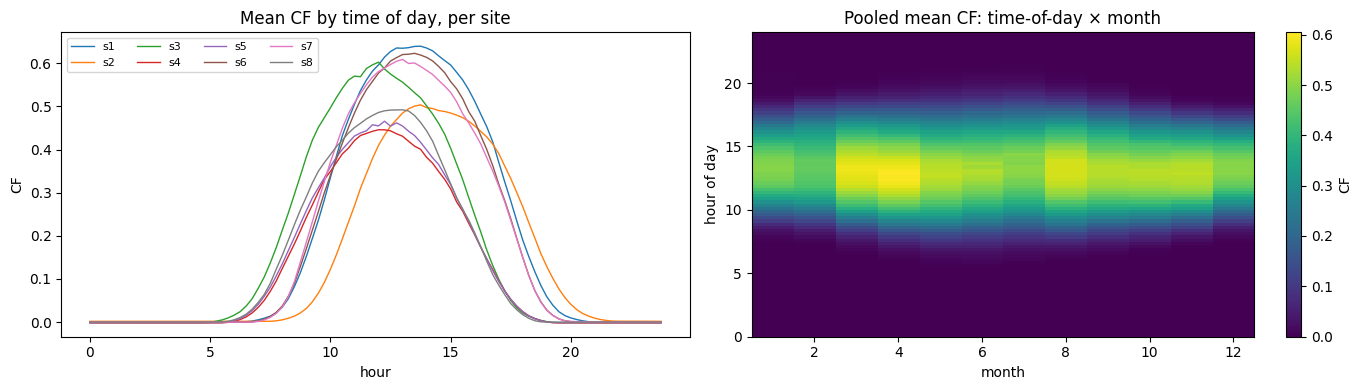

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for s in sorted(stations):
    prof = stations[s].groupby("tod")["cf"].mean()
    ax[0].plot(prof.index / 60, prof.values, lw=1, label=f"s{s}")
ax[0].set_title("Mean CF by time of day, per site"); ax[0].set_xlabel("hour")
ax[0].set_ylabel("CF"); ax[0].legend(ncol=4, fontsize=8)

piv = full.pivot_table(index="tod", columns="month", values="cf", aggfunc="mean")
im = ax[1].imshow(piv.values, aspect="auto", origin="lower", cmap="viridis",
                  extent=[0.5, 12.5, 0, 24])
ax[1].set_title("Pooled mean CF: time-of-day × month"); ax[1].set_xlabel("month")
ax[1].set_ylabel("hour of day"); fig.colorbar(im, ax=ax[1], label="CF")
plt.tight_layout(); plt.show()

## 4. Feature distributions

The four requested drivers — **irradiance, air temperature, atmospheric
pressure** (plus humidity). Per-site temperature and pressure differ markedly
(different geographies / elevations).

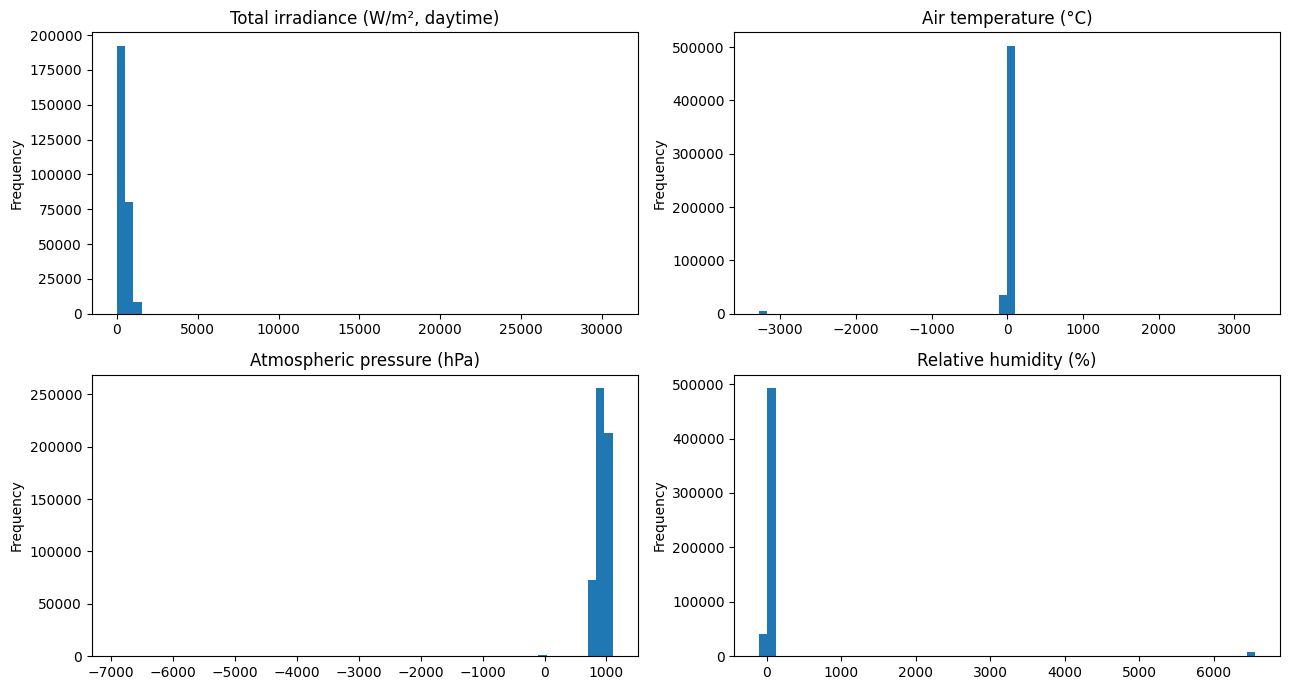

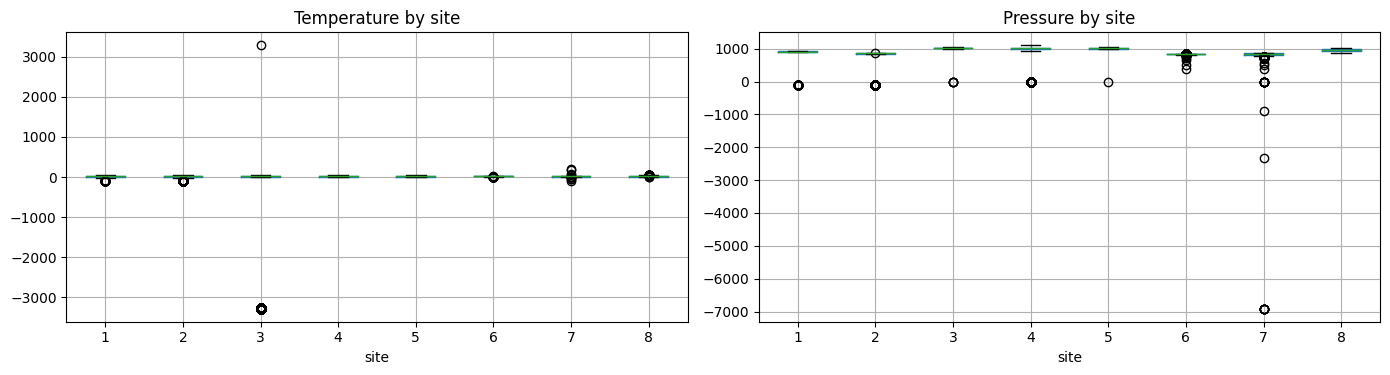

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
day["irr_total"].plot(kind="hist", bins=60, ax=ax[0, 0]); ax[0, 0].set_title("Total irradiance (W/m², daytime)")
full["temp"].plot(kind="hist", bins=60, ax=ax[0, 1]); ax[0, 1].set_title("Air temperature (°C)")
full["pressure"].plot(kind="hist", bins=60, ax=ax[1, 0]); ax[1, 0].set_title("Atmospheric pressure (hPa)")
full["humidity"].plot(kind="hist", bins=60, ax=ax[1, 1]); ax[1, 1].set_title("Relative humidity (%)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
full.boxplot(column="temp", by="site", ax=ax[0]); ax[0].set_title("Temperature by site"); ax[0].set_xlabel("site")
full.boxplot(column="pressure", by="site", ax=ax[1]); ax[1].set_title("Pressure by site"); ax[1].set_xlabel("site")
plt.suptitle(""); plt.tight_layout(); plt.show()

## 5. Feature–power relationships

The core question for forecasting: how do the drivers relate to power?
Irradiance → power is expected to be near-linear; temperature has a secondary
(efficiency) effect. Left: irradiance vs CF (daytime sample). Right: Pearson
correlation of drivers with CF, pooled over daytime rows.

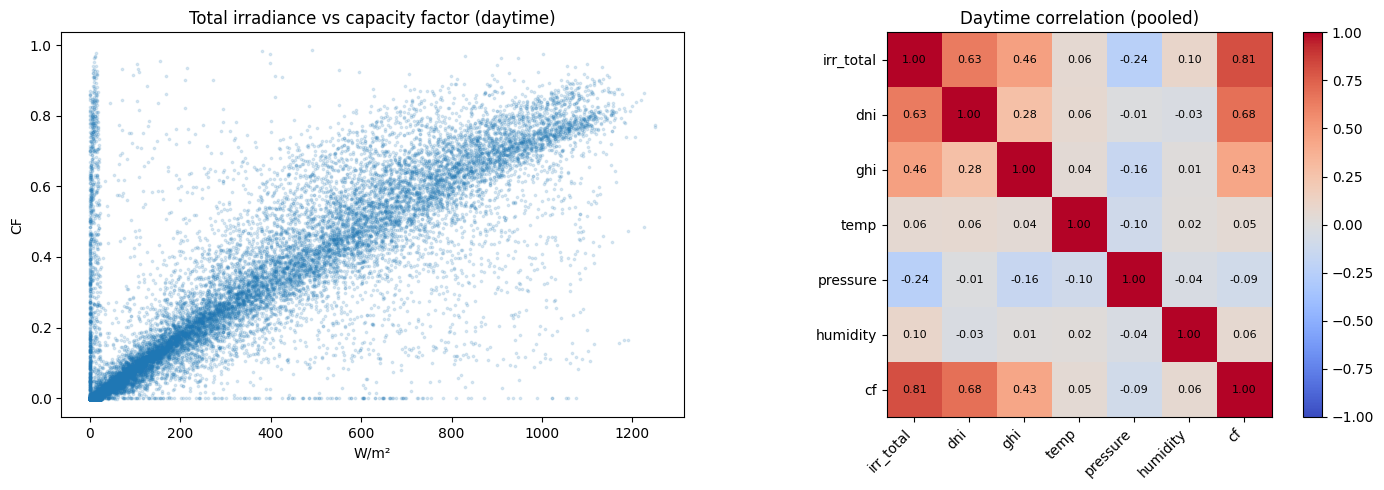

per-site corr(total irradiance, CF), daytime:
site
1    0.896
2    0.853
3    0.321
4    0.955
5    0.972
6    0.979
7    0.799
8    0.794


In [8]:
samp = day.dropna(subset=["irr_total", "cf"]).sample(min(20000, len(day)), random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(samp["irr_total"], samp["cf"], s=3, alpha=.15)
ax[0].set_title("Total irradiance vs capacity factor (daytime)")
ax[0].set_xlabel("W/m²"); ax[0].set_ylabel("CF")

corr_cols = ["irr_total", "dni", "ghi", "temp", "pressure", "humidity", "cf"]
corr = day[corr_cols].corr()
im = ax[1].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax[1].set_xticks(range(len(corr_cols))); ax[1].set_xticklabels(corr_cols, rotation=45, ha="right")
ax[1].set_yticks(range(len(corr_cols))); ax[1].set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax[1].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax[1].set_title("Daytime correlation (pooled)")
fig.colorbar(im, ax=ax[1], fraction=.046)
plt.tight_layout(); plt.show()

print("per-site corr(total irradiance, CF), daytime:")
print(day.groupby("site").apply(lambda g: g["irr_total"].corr(g["cf"])).round(3).to_string())

## 6. Physical consistency checks

Sanity checks that flag cleaning needs: generation reported when irradiance is
zero (night), irradiance channel ordering, and the negative-power tail.

In [9]:
eps = 1e-6
night = full[full["irr_total"] <= 0]
print("rows with irradiance==0 (night):", len(night))
print("  of those, power > 0.5% capacity:", int((night["cf"] > 0.005).sum()),
      "(spurious night generation)")
print("  of those, power < 0:", int((night["power"] < 0).sum()),
      "(inverter self-consumption at night)")
print("\nnegative power: min CF =", round(full["cf"].min(), 4),
      "| affected sites:", sorted(full.loc[full["power"] < 0, "site"].unique().tolist()))
print("irradiance ordering — rows where GHI > total irradiance:",
      int((full["ghi"] > full["irr_total"] + eps).sum()))

rows with irradiance==0 (night): 260796
  of those, power > 0.5% capacity: 4105 (spurious night generation)
  of those, power < 0: 67752 (inverter self-consumption at night)

negative power: min CF = -0.0049 | affected sites: [3, 4, 5]
irradiance ordering — rows where GHI > total irradiance: 31207


## Takeaways & cleaning checklist

**Shape**: 8 PV stations, 30–130 MW (≈545 MW total), 15-min, 2019–2020. Use
**capacity factor (power/capacity)** to compare stations.

**Coverage**: sites 1,2,4,5,6,7 are full 2 years; **site 3 stops 2020-07** (~1.5 yr),
**site 8** is slightly short — handle unequal lengths per station.

**Quality issues to clean (raw data)**:
- **String junk** in numeric columns (sites 5/6/7, thousands of cells) → coerce to NaN then impute/drop.
- **Negative power** at night (sites 3/4/5) → inverter self-draw; clip to 0 or keep as a known offset.
- A few **nulls** (site 4) and check duplicate timestamps.
- **Night rows** with irradiance 0 dominate — decide whether to model daytime-only.

**Signal**: irradiance is the dominant, near-linear driver of power (high per-site
correlation); temperature/pressure/humidity are secondary. This matches the
competition's premise that these are the key input features.

**Next**: pick a per-station cleaning + daytime policy, normalise to CF, then reuse
the `vanilla_transformer` windowing with **one frame per (station, continuous
segment)** so windows never cross a station or a gap.